# Exercise 2: Statistical Visualization

This exercise focuses on data visualization using `matplotlib` and `seaborn`. It covers the **M3-2: Statistical Visualization** learning outcomes. We will primarily use the Palmer Penguins dataset. Work through the sections in order.


In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("penguins")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## B. Subplots and Grids

**1.** Using a seaborn **figure-level** function (like `sns.relplot` or `sns.displot`), create subplots using the `col` and `row` parameters. For example, plot `flipper_length_mm` vs `body_mass_g` across columns for `sex` and rows for `island`.

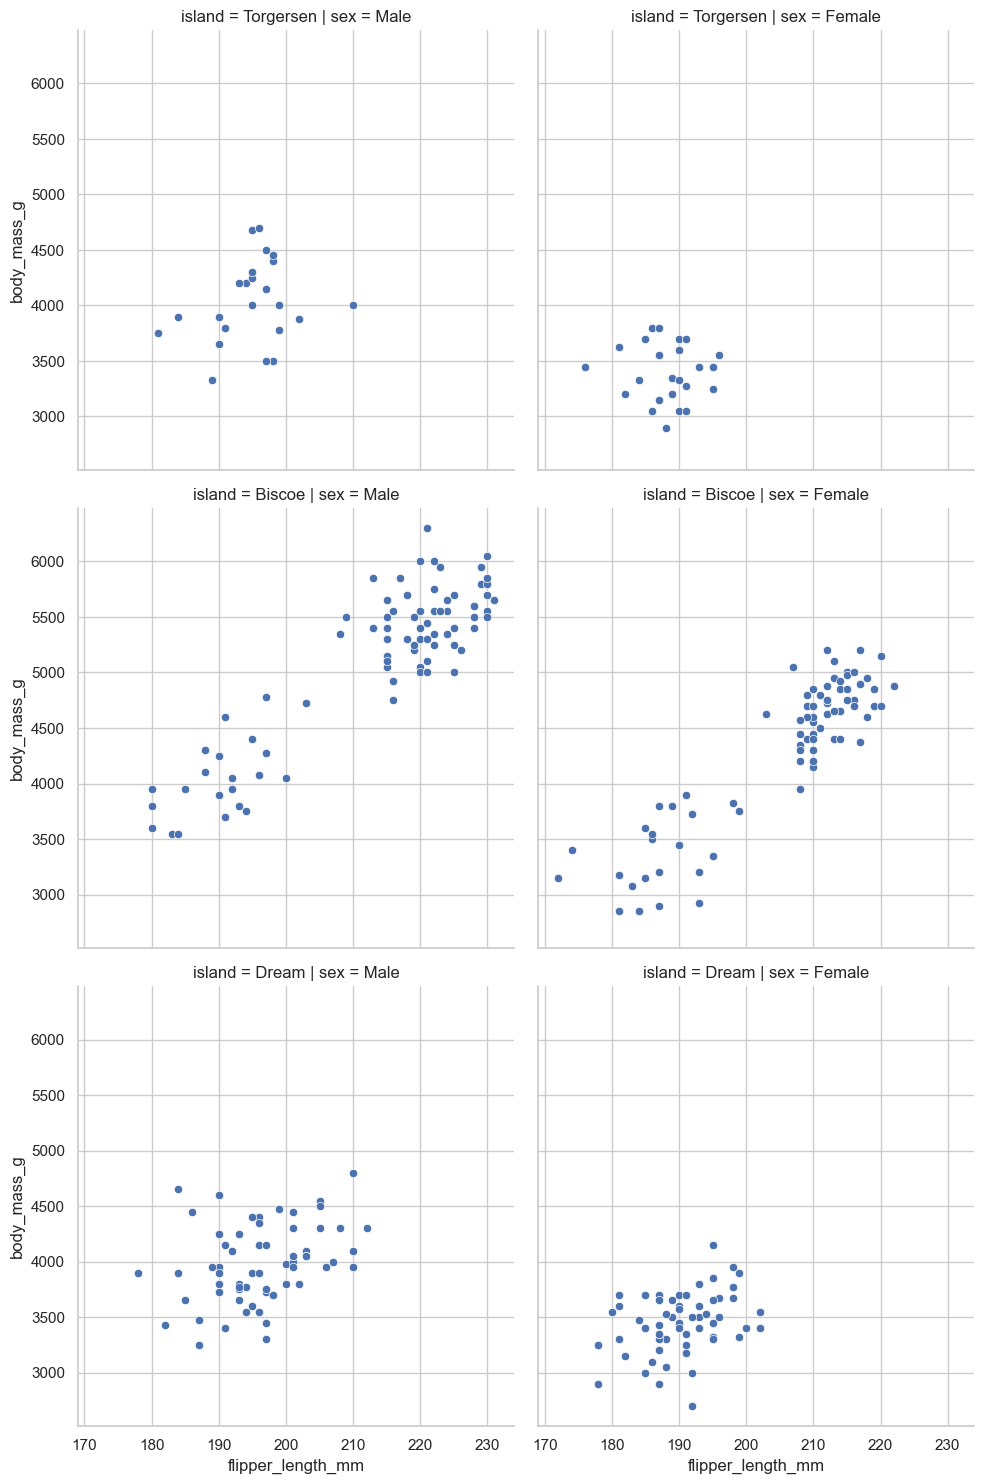

In [95]:
g = sns.relplot(
    data=df,
    x="flipper_length_mm",
    y="body_mass_g",
    col="sex",    
    row="island", 
    kind="scatter"
)

plt.show()

**2.** Using **axes-level** functions, create a figure with subplots (e.g., 1 row and 2 columns) using `plt.subplots`. 
- Plot a scatterplot of `bill_length_mm` vs `bill_depth_mm` on the first axes (`ax1`).
- Plot a boxplot (or another axes-level plot of your choice) of `bill_length_mm` by `species` on the second axes (`ax2`).
- Make sure to use `sharey=True` (or `sharex=True`) where appropriate so the subplots are linked on the shared dimension.

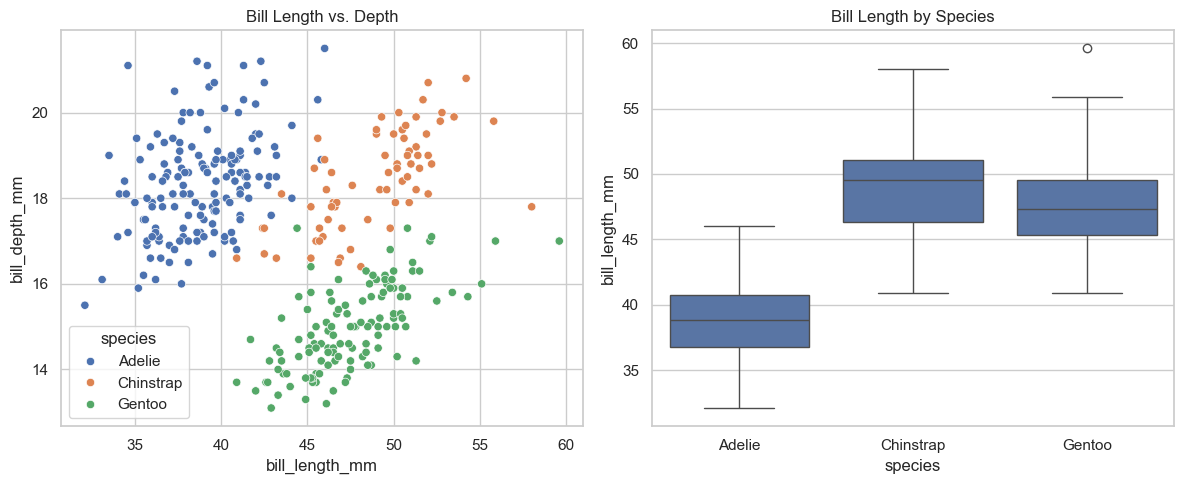

In [96]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Scatterplot on the first axes (ax1)
sns.scatterplot(
    data=df, 
    x="bill_length_mm", 
    y="bill_depth_mm", 
    hue="species", 
    ax=ax1
)
ax1.set_title("Bill Length vs. Depth")

# Plot 2: Boxplot on the second axes (ax2)
sns.boxplot(
    data=df, 
    x="species", 
    y="bill_length_mm", 
    ax=ax2
)
ax2.set_title("Bill Length by Species")

plt.tight_layout()
plt.show()

## C. Visualizing Distributions

**1.** Write code to show a **box plot** of `flipper_length_mm` separated by `species`.

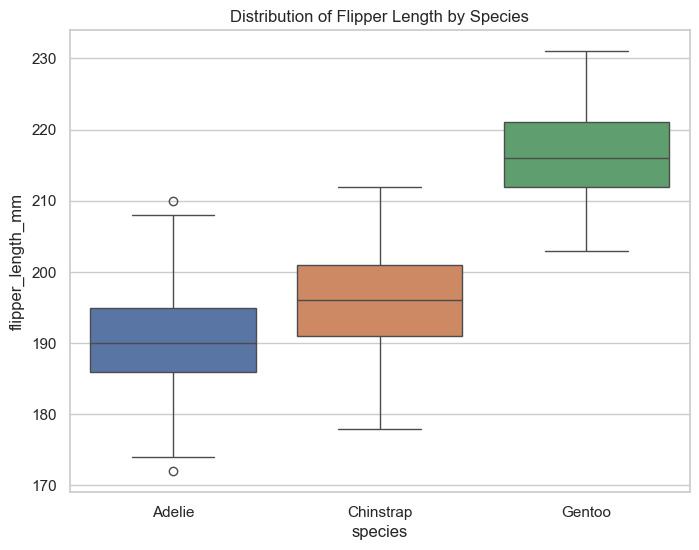

In [97]:
# Create the box plot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="species", y="flipper_length_mm", hue="species")

# Add a title for clarity
plt.title("Distribution of Flipper Length by Species")

plt.show()



**2.** Show two distributions on the same figure axes: plot the distribution of `body_mass_g` grouped by `sex` (e.g., using `sns.kdeplot`, or `sns.histplot` with overlapping transparent bins).



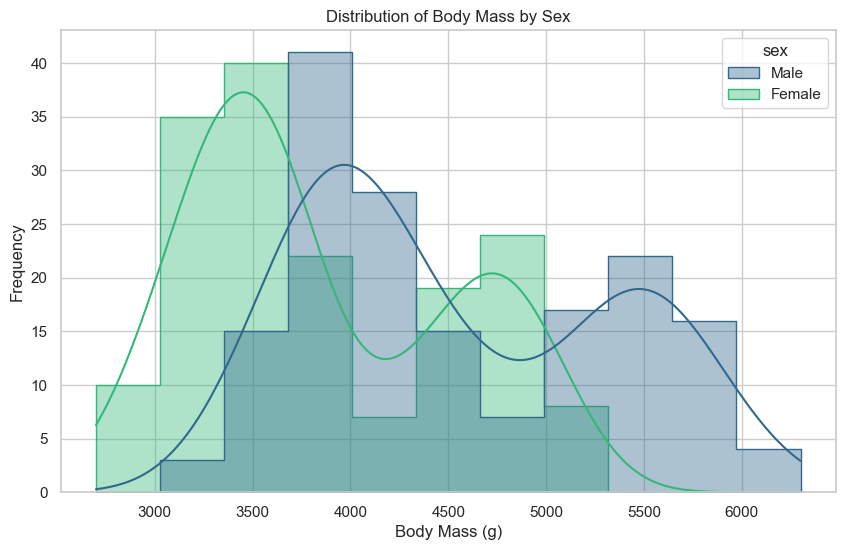

In [98]:
# Create the overlapping distribution plot
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="body_mass_g",
    hue="sex",
    kde=True,          # Adds the Kernel Density Estimate line
    element="step",    # Makes the bars outlined for better visibility
    palette="viridis",
    alpha=0.4        # Sets transparency for overlapping areas
)

plt.title("Distribution of Body Mass by Sex")
plt.xlabel("Body Mass (g)")
plt.ylabel("Frequency")

plt.show()



**3.** Plot the Empirical Cumulative Distribution Function (**ECDF**) for `body_mass_g`, split by `species`. Briefly interpret what the plot tells you about how the species compare in weight.



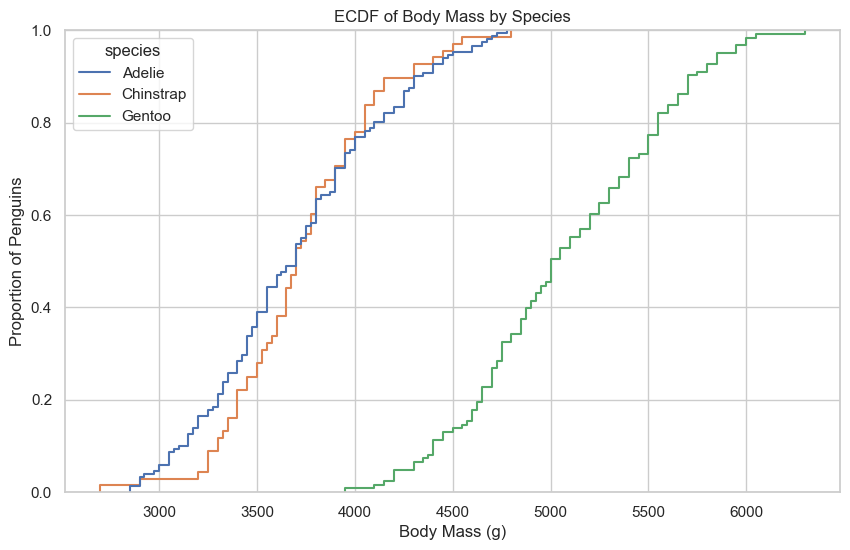

In [99]:
# Create the ECDF plot
plt.figure(figsize=(10, 6))
sns.ecdfplot(data=df, x="body_mass_g", hue="species")

# Add informative labels
plt.title("ECDF of Body Mass by Species")
plt.xlabel("Body Mass (g)")
plt.ylabel("Proportion of Penguins")

plt.show()



*(Your interpretation here)*



**4.** Plot a **bi-variate histogram** using `sns.histplot` showing `bill_length_mm` on the x-axis and `bill_depth_mm` on the y-axis. What does the intensity mapping (the color blocks) represent?



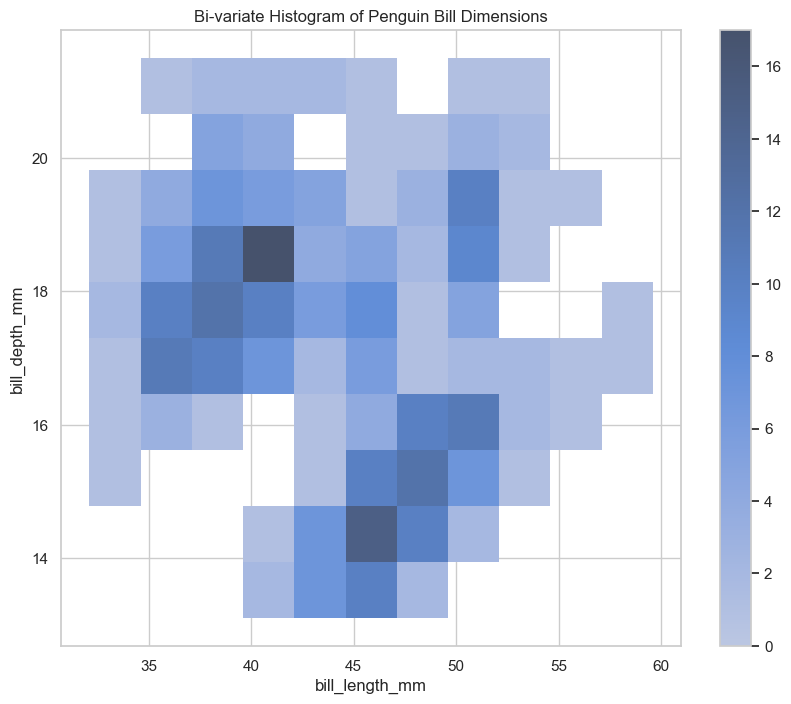

In [100]:
# Create the bi-variate histogram
plt.figure(figsize=(10, 8))
sns.histplot(
    data=df, 
    x="bill_length_mm", 
    y="bill_depth_mm", 
    cbar=True  # Adds the color scale bar for interpretation
)

plt.title("Bi-variate Histogram of Penguin Bill Dimensions")
plt.show()



*(Your interpretation here)*



## D. Categorical Data

**1.** Visualize numerical vs categorical relationships using `sns.catplot()`. Plot `bill_depth_mm` across different `island`s. Experiment with different categorical plot kinds (e.g., `kind='violin'` or `kind='swarm'`).

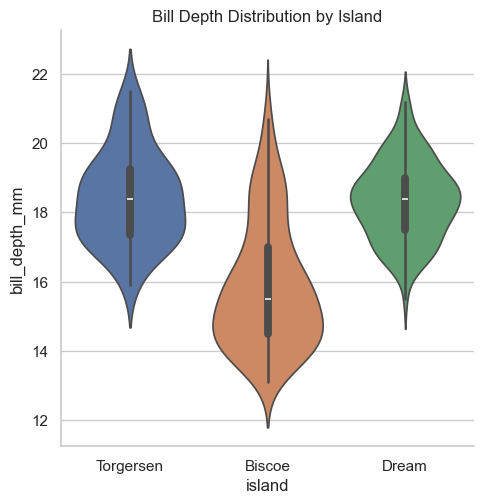

In [101]:
sns.catplot(
    data=df, 
    x="island", 
    y="bill_depth_mm", 
    
    kind="violin", 
    #kind="swarm",
    hue="island",
    )
plt.title("Bill Depth Distribution by Island")
plt.show()

**2.** Visualize multiple categorical variables in one plot. Show a count of penguins by `island`, and further separate the counts by `species` (using the `hue` parameter in a count plot or a similar approach).

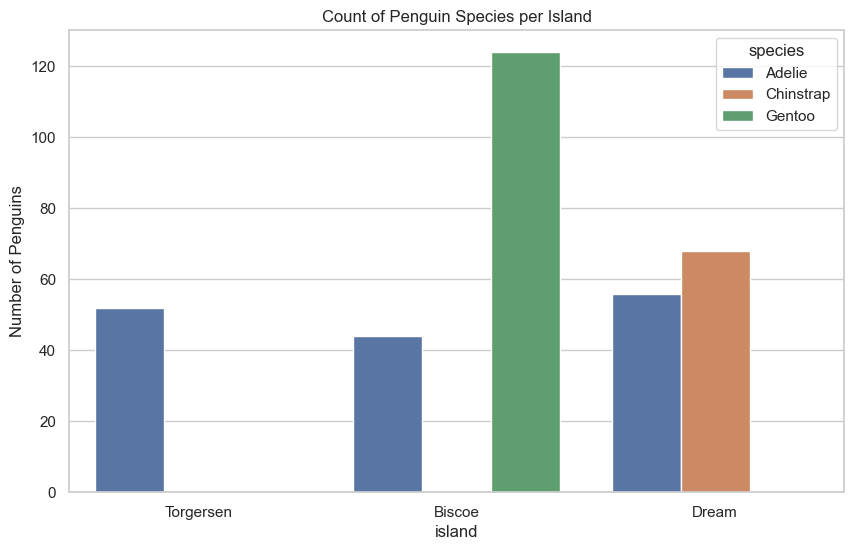

In [102]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df, 
    x="island", 
    hue="species", 
)

plt.title("Count of Penguin Species per Island")
plt.ylabel("Number of Penguins")
plt.show()

## E. Relational Plots and Aesthetics

**1.** Relate two numerical variables using a simple **scatter plot**: plot `bill_length_mm` vs `flipper_length_mm`.

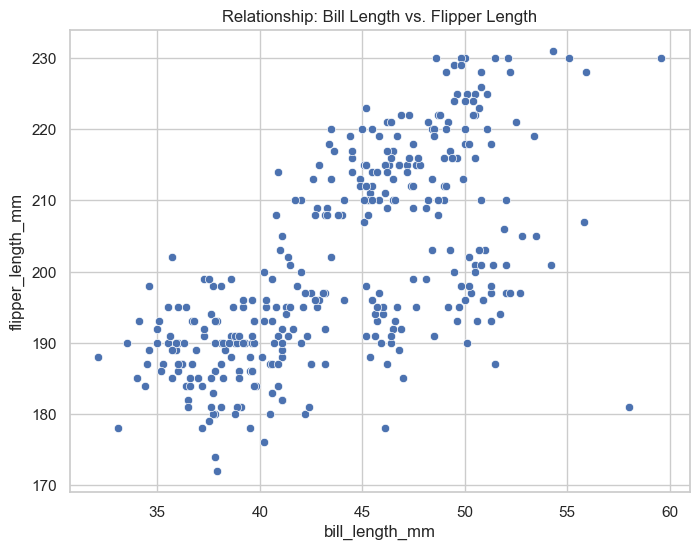

In [103]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="bill_length_mm", y="flipper_length_mm")

plt.title("Relationship: Bill Length vs. Flipper Length")
plt.show()

**2.** Enhance the scatter plot from the previous step by using different **colors** (`hue`), **markers** (`style`), and **sizes** (`size`) based on other variables in the dataset. Make the plot visually distinct and ensure it is readable.

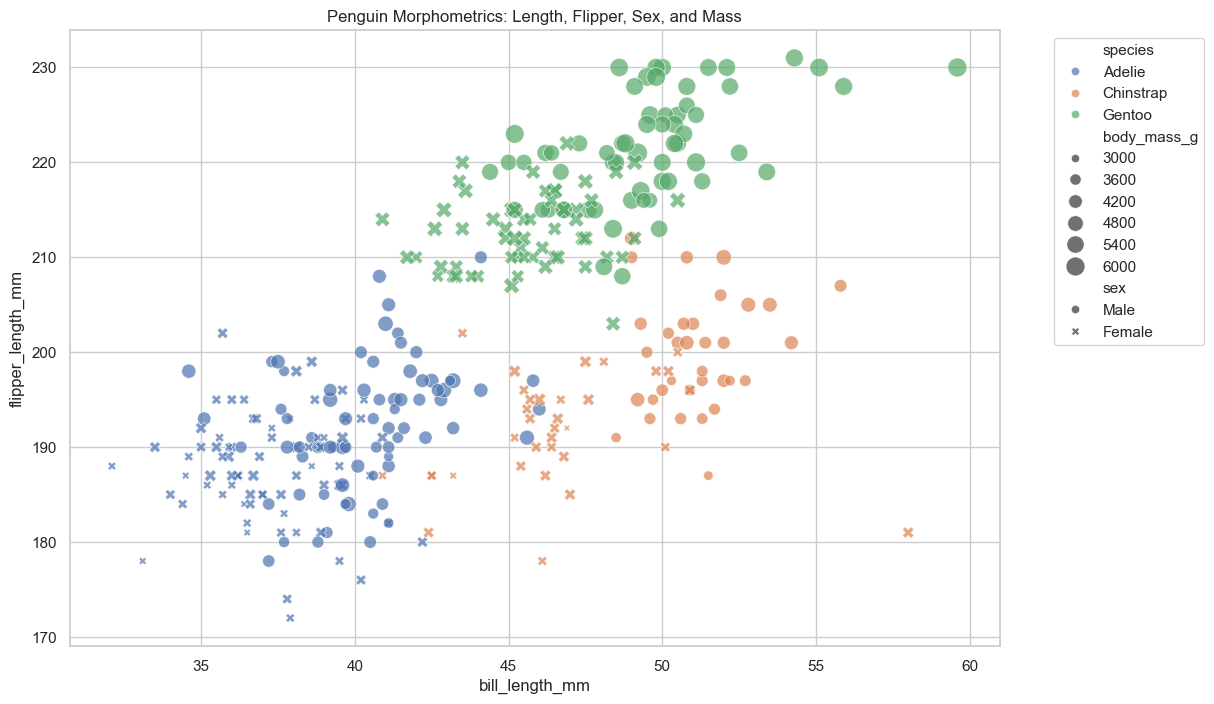

In [104]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=penguins, 
    x="bill_length_mm", 
    y="flipper_length_mm", 
    hue="species",      
    style="sex",        
    size="body_mass_g", 
    sizes=(20, 200),    
    alpha=0.7           
)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Penguin Morphometrics: Length, Flipper, Sex, and Mass")
plt.show()